# TRANS-01 Project 5 
**Civil Engineering Analysis II | Spring 2026**
### Project Designers: Logan Baardson, Arturo Garcia, Nay Law Htoo, Ryan Kramer
#### Client: Nebraska Department of Transportation (NDOT)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

# Dataset Description

The dataset tracks multiple agent types including Automated Vehicles (AVs), non-automated Passenger Cars, Pedestrians, Trucks, Bicycles, Buses, Scooters, and Motorcycles

#### Key Columns used in this analysis:
- `id` - unique agent identifier
- `time` - time (in 0.1 second intervals)
- `xloc_kf`,`yloc_kf` - filtered x and y positions (meters)
- `speed_magnitude`- overall speed of the agent (m/s)
- `accel_magnitude` - overall acceleration of the agent (m/s^2)
- `agent_type_label` - label for the agent category

#### This data was cleaned before to filter out data and make things easier


In [2]:
# Load and structure the dataset
tgsim_data = pd.read_csv('Cleaned_TGSIM_Foggy_Bottom.csv')
tgsim_data = pd.DataFrame(tgsim_data)

# This is to strip any leading/trailing whitespace from the agent type labels
tgsim_data['agent_type_label'] = tgsim_data['agent_type_label'].str.strip()

tgsim_data.columns

Index(['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x',
       'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y',
       'length_smoothed', 'width_smoothed', 'type_most_common',
       'speed_magnitude', 'accel_magnitude', 'agent_type_label'],
      dtype='object')

In [3]:
tgsim_data.head(5)

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common,speed_magnitude,accel_magnitude,agent_type_label
0,165,3700.0,183.966348,308.305096,36,0.108236,6.005233,0.018661,0.802440,15.0,2.413078,7,6.006209,-0.802656,Trucks
1,165,3700.1,183.978291,308.896475,36,0.119433,5.913793,0.111968,-0.914408,15.0,2.413078,7,5.914998,-0.921238,Trucks
2,165,3700.2,183.991354,309.478151,36,0.130630,5.816753,0.111968,-0.970392,15.0,2.413078,7,5.818220,-0.976830,Trucks
3,165,3700.3,184.004604,310.048069,36,0.132496,5.699187,0.018661,-1.175667,15.0,2.413078,7,5.700727,-1.175815,Trucks
4,165,3700.4,184.017107,310.605112,36,0.125031,5.570423,-0.074646,-1.287635,15.0,2.413078,7,5.571826,-1.289797,Trucks


In [4]:
tgsim_data.describe()

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common,speed_magnitude,accel_magnitude
count,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000
mean,4738.010860,3801.804675,81.131044,266.847530,25.789479,-0.121062,-0.723644,0.004984,-0.011585,4.503755,1.390293,2.416096,2.607072,-0.488974
std,5232.987271,55.535699,56.068695,73.696055,14.171178,1.717602,4.483481,0.417142,0.862168,3.047355,0.924573,1.642860,4.097946,0.823651
min,165.000000,3700.000000,0.018848,134.375960,1.000000,-12.488198,-21.540835,-5.691722,-8.658882,0.000000,0.000000,0.000000,0.000000,-8.660893
25%,1668.000000,3759.400000,38.951907,169.729205,14.000000,-0.110102,-0.042921,-0.055984,-0.055984,0.000000,0.000000,0.000000,0.015045,-0.544068
50%,1705.000000,3800.600000,48.622236,307.943252,29.000000,-0.001866,0.001866,0.000000,0.000000,6.197281,1.691488,3.000000,0.736101,-0.125184
75%,6522.000000,3845.700000,129.268712,326.582242,38.000000,0.018661,0.182882,0.055984,0.055984,6.200000,2.200000,3.000000,2.556908,-0.037323
max,19268.000000,3900.000000,196.837478,357.065053,49.000000,14.055754,17.556630,4.422748,6.120934,15.000000,2.750000,7.000000,21.543662,0.000000


In [5]:
print(tgsim_data['agent_type_label'].value_counts())

agent_type_label
Passenger Cars (Non-automated)    47143
Persons (Pedestrians)             18290
Trucks                             2724
Automated Vehicles                 1975
Bicycles                            498
Buses                               495
Scooters                            210
Motorcycles                          26
Name: count, dtype: int64


In [6]:
# Group by agent type and compute summary statistics
tgsim_grouped = tgsim_data.groupby(['agent_type_label'])

summary_table = tgsim_grouped.agg(
    num_observations = ('speed_magnitude', 'count'),
    num_agents       = ('id', 'nunique'),
    mean_speed_ms    = ('speed_magnitude', 'mean'),
    std_speed_ms     = ('speed_magnitude', 'std'),
    mean_accel_ms2   = ('accel_magnitude', 'mean'),
    std_accel_ms2    = ('accel_magnitude', 'std'))

In [7]:
summary_table = summary_table.sort_values('mean_speed_ms', ascending = False)

summary_table

,num_observations,num_agents,mean_speed_ms,std_speed_ms,mean_accel_ms2,std_accel_ms2
agent_type_label,,,,,,
Motorcycles,26,1,5.381609,0.600524,-1.421059,0.995754
Scooters,210,8,4.426109,1.300884,-1.045332,0.724872
Passenger Cars (Non-automated),47143,157,3.256133,4.832910,-0.580965,0.969864
Automated Vehicles,1975,1,2.470593,2.144249,-0.383804,0.447731
Buses,495,2,1.830558,2.445692,-0.570656,0.684963
Bicycles,498,8,1.727159,2.088950,-0.509144,0.683508
Persons (Pedestrians),18290,380,1.302075,0.768391,-0.302187,0.239919
Trucks,2724,7,0.370550,1.440816,-0.157036,0.457562


<Figure size 1400x600 with 0 Axes>

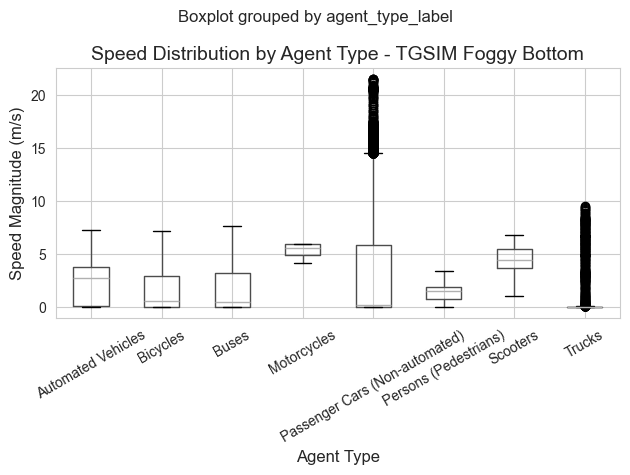

In [8]:
plt.figure(figsize = (14, 6))
tgsim_data.boxplot(column = 'speed_magnitude', by = 'agent_type_label', rot = 30)

plt.xlabel('Agent Type', fontsize = 12)
plt.ylabel('Speed Magnitude (m/s)', fontsize = 12)

plt.title('Speed Distribution by Agent Type - TGSIM Foggy Bottom', fontsize = 14)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

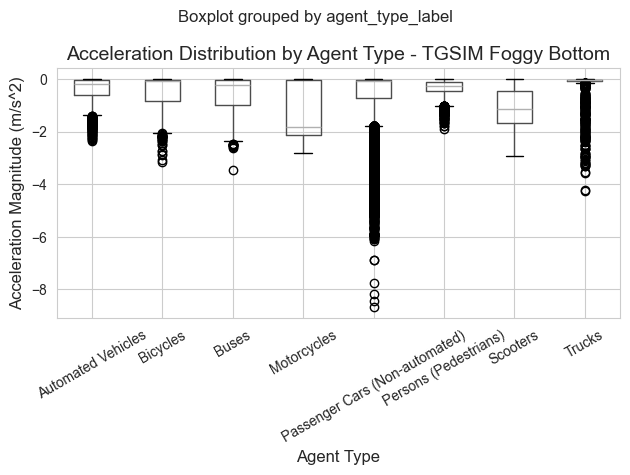

In [9]:
plt.figure(figsize = (14, 6))

tgsim_data.boxplot(column = 'accel_magnitude', by = 'agent_type_label', rot = 30)

plt.xlabel('Agent Type', fontsize = 12)
plt.ylabel('Acceleration Magnitude (m/s^2)', fontsize = 12)

plt.title('Acceleration Distribution by Agent Type - TGSIM Foggy Bottom', fontsize = 14)

plt.tight_layout()
plt.show()

#### Setting up the Speed Over Time Comparison
Here we filter the dataset by agent type and compute the average speed across all agents of that type at each 0.1-second time step. This gives us a time-series view of how AV speed compares to non-automated passenger cars throughout the 200-second window.

In [10]:
# We filter each agent type and calculate mean speed at each time step
av_speed_over_time  = tgsim_data[tgsim_data['agent_type_label'] == 'Automated Vehicles'].groupby('time')['speed_magnitude'].mean()
car_speed_over_time = tgsim_data[tgsim_data['agent_type_label'] == 'Passenger Cars (Non-automated)'].groupby('time')['speed_magnitude'].mean()

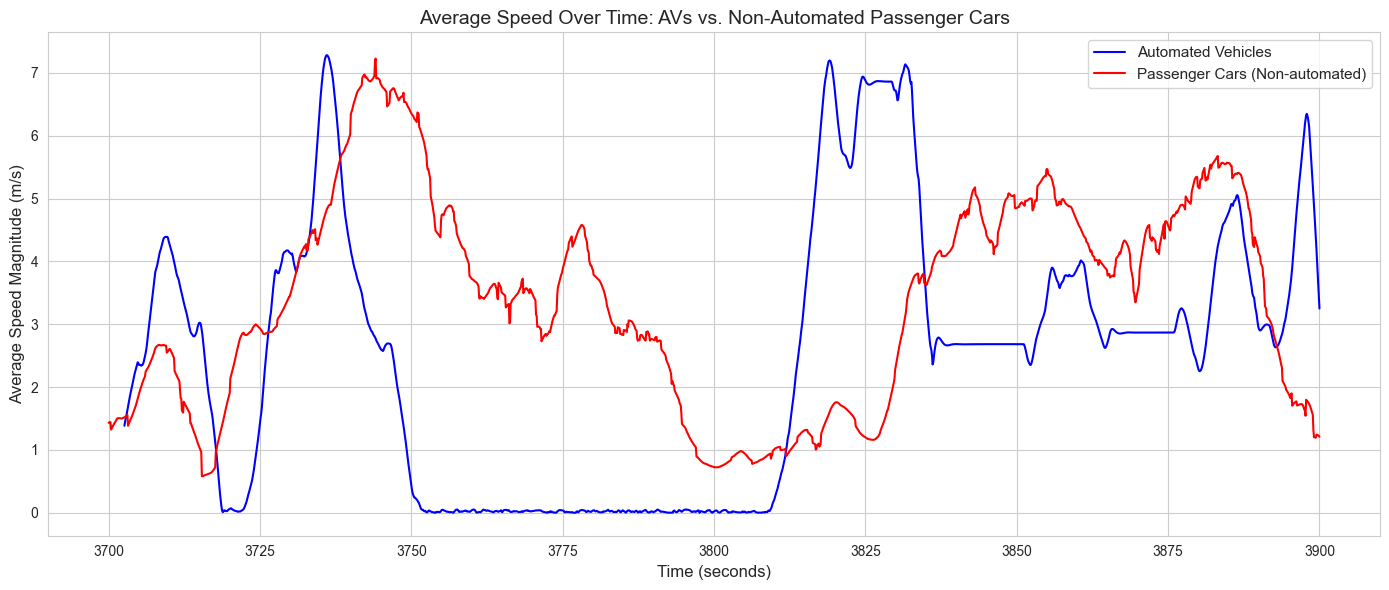

In [11]:
plt.figure(figsize = (14, 6))

plt.plot(av_speed_over_time.index,  av_speed_over_time.values,  label = 'Automated Vehicles',            color = 'blue',  linewidth = 1.5)
plt.plot(car_speed_over_time.index, car_speed_over_time.values, label = 'Passenger Cars (Non-automated)', color = 'red',   linewidth = 1.5)

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Average Speed Magnitude (m/s)', fontsize = 12)

plt.title('Average Speed Over Time: AVs vs. Non-Automated Passenger Cars', fontsize = 14)
plt.legend(fontsize = 11)
plt.grid(True, alpha = 1)

plt.tight_layout()
plt.show()

Based on the initial results above:

- The summary table shows that Automated Vehicles have lower speed variability (std_speed_ms) compared to non-automated Passenger Cars, which supports the claim that AVs are more predictable.
- The acceleration boxplot shows differences in braking and accelerating patterns between agent types. Further analysis will count the number of deceleration events per agent to quantify disruptive behavior.
- The speed-over-time line plot shows how AV average speed compares to passenger cars at each moment across the 200-second window.

---
#### Function 1: `classify_behavior(accel)`

This function takes an acceleration value and classifies it into one of five behavior categories: Hard Deceleration, Mild Deceleration**, Steady, Mild Acceleration, or Hard Acceleration. It is applied row-by-row to the `accel_magnitude` column using `.apply()`, creating a new column `behavior_label` in the dataset.

This allows us to compare the distribution of driving behaviors across agent types — for example, whether AVs spend more time in the Steady category than human-driven vehicles, which would support the claim that they are more predictable.

In [15]:
# Function 1: Classify driving behavior based on acceleration value
def classify_behavior(accel):
    if accel <= -2.0:
        return 'Hard Deceleration'
    elif -2.0 < accel <= -0.5:
        return 'Mild Deceleration'
    elif -0.5 < accel <= 0.5:
        return 'Steady'
    elif 0.5 < accel <= 2.0:
        return 'Mild Acceleration'
    else:
        return 'Hard Acceleration'

# Apply the function to each row in the accel_magnitude column
tgsim_data['behavior_label'] = tgsim_data['accel_magnitude'].apply(classify_behavior)
tgsim_data.head(5)

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common,speed_magnitude,accel_magnitude,agent_type_label,behavior_label
0,165,3700.0,183.966348,308.305096,36,0.108236,6.005233,0.018661,0.802440,15.0,2.413078,7,6.006209,-0.802656,Trucks,Mild Deceleration
1,165,3700.1,183.978291,308.896475,36,0.119433,5.913793,0.111968,-0.914408,15.0,2.413078,7,5.914998,-0.921238,Trucks,Mild Deceleration
2,165,3700.2,183.991354,309.478151,36,0.130630,5.816753,0.111968,-0.970392,15.0,2.413078,7,5.818220,-0.976830,Trucks,Mild Deceleration
3,165,3700.3,184.004604,310.048069,36,0.132496,5.699187,0.018661,-1.175667,15.0,2.413078,7,5.700727,-1.175815,Trucks,Mild Deceleration
4,165,3700.4,184.017107,310.605112,36,0.125031,5.570423,-0.074646,-1.287635,15.0,2.413078,7,5.571826,-1.289797,Trucks,Mild Deceleration


In [16]:
# Count the behavior distribution for each agent type
behavior_summary = tgsim_data.groupby(['agent_type_label', 'behavior_label']).size().reset_index(name = 'count')
# Pivot so each behavior category is a column for easier comparison
behavior_pivot = behavior_summary.pivot(index = 'agent_type_label', columns = 'behavior_label', values = 'count').fillna(0)
behavior_pivot

behavior_label,Hard Deceleration,Mild Deceleration,Steady
agent_type_label,,,
Automated Vehicles,15.0,578.0,1382.0
Bicycles,30.0,150.0,318.0
Buses,26.0,170.0,299.0
Motorcycles,10.0,8.0,8.0
Passenger Cars (Non-automated),4547.0,9438.0,33158.0
Persons (Pedestrians),0.0,4006.0,14284.0
Scooters,9.0,147.0,54.0
Trucks,58.0,114.0,2552.0


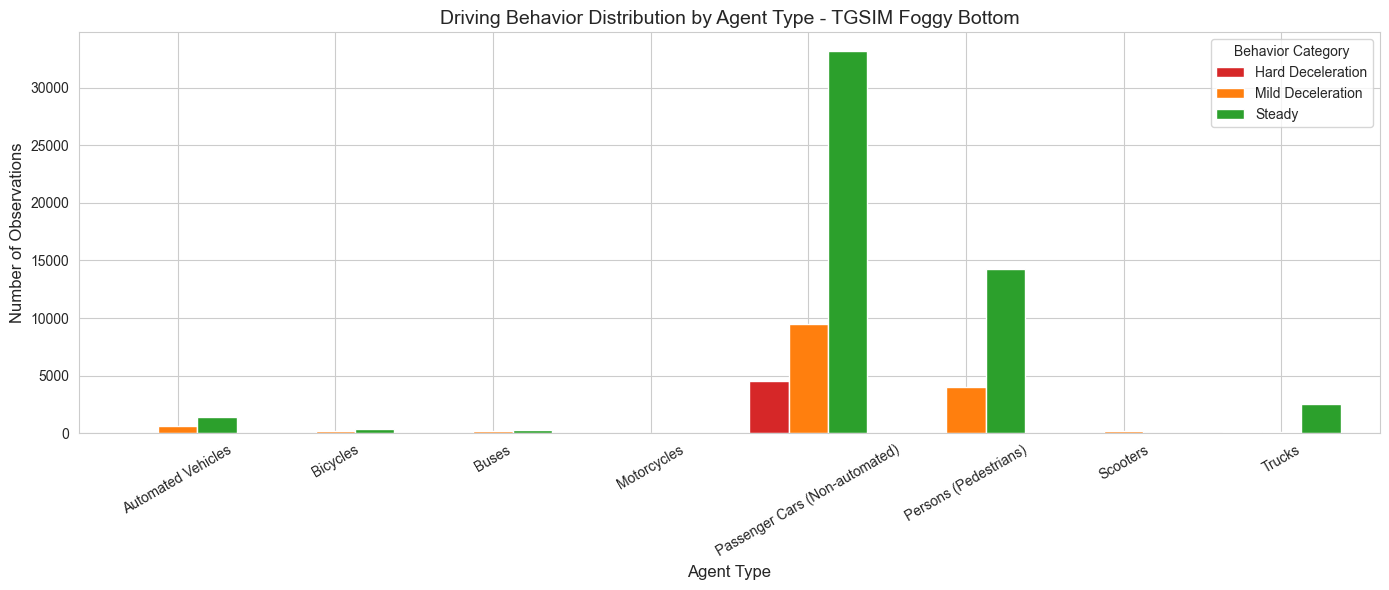

In [23]:
# Visualize behavior distribution as a grouped bar chart
behavior_order  = ['Hard Deceleration', 'Mild Deceleration', 'Steady', 'Mild Acceleration', 'Hard Acceleration']
behavior_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
behavior_plot_data = behavior_pivot[[col for col in behavior_order if col in behavior_pivot.columns]]
ax = behavior_plot_data.plot(kind = 'bar', figsize = (14, 6), color = behavior_colors,
                             edgecolor = 'white', width = 0.75)
plt.xlabel('Agent Type', fontsize = 12)
plt.ylabel('Number of Observations', fontsize = 12)
plt.title('Driving Behavior Distribution by Agent Type - TGSIM Foggy Bottom', fontsize = 14)
plt.xticks(rotation = 30, fontsize = 10)
plt.legend(title = 'Behavior Category', fontsize = 10)
plt.tight_layout()
plt.show()

#### Function 2: `count_decel_events(df, threshold)`

This function takes the full dataset and a deceleration threshold (default: -2.0 m/s²) and returns a summary table showing the total number of hard deceleration events and the average number of events per agent for each agent type. A "deceleration event" is defined as any timestep where the `accel_magnitude` falls at or below the threshold.

This directly addresses the client request to "count the number of deceleration events, which may indicate disruptive behavior" and allows us to compare how disruptive each agent type is at the intersection.

In [24]:
# Function 2: Count hard deceleration events per agent type
def count_decel_events(df, threshold = -2.0):
    # Filter rows where acceleration is at or below the threshold
    hard_decel_df = df[df['accel_magnitude'] <= threshold]
    # Count total events and unique agents per type
    decel_summary = hard_decel_df.groupby('agent_type_label').agg(
        total_decel_events = ('id', 'count'),
        num_agents         = ('id', 'nunique')
    )
    # Calculate average events per individual agent
    decel_summary['avg_events_per_agent'] = (decel_summary['total_decel_events'] /
                                              decel_summary['num_agents']).round(2)
    return decel_summary.sort_values('avg_events_per_agent', ascending = False)
# Call the function with the default threshold of -2.0 m/s^2
decel_results = count_decel_events(tgsim_data, threshold = -2.0)
decel_results

,total_decel_events,num_agents,avg_events_per_agent
agent_type_label,,,
Passenger Cars (Non-automated),4547,128,35.52
Trucks,58,3,19.33
Automated Vehicles,15,1,15.00
Bicycles,30,2,15.00
Buses,26,2,13.00
Motorcycles,10,1,10.00
Scooters,9,1,9.00


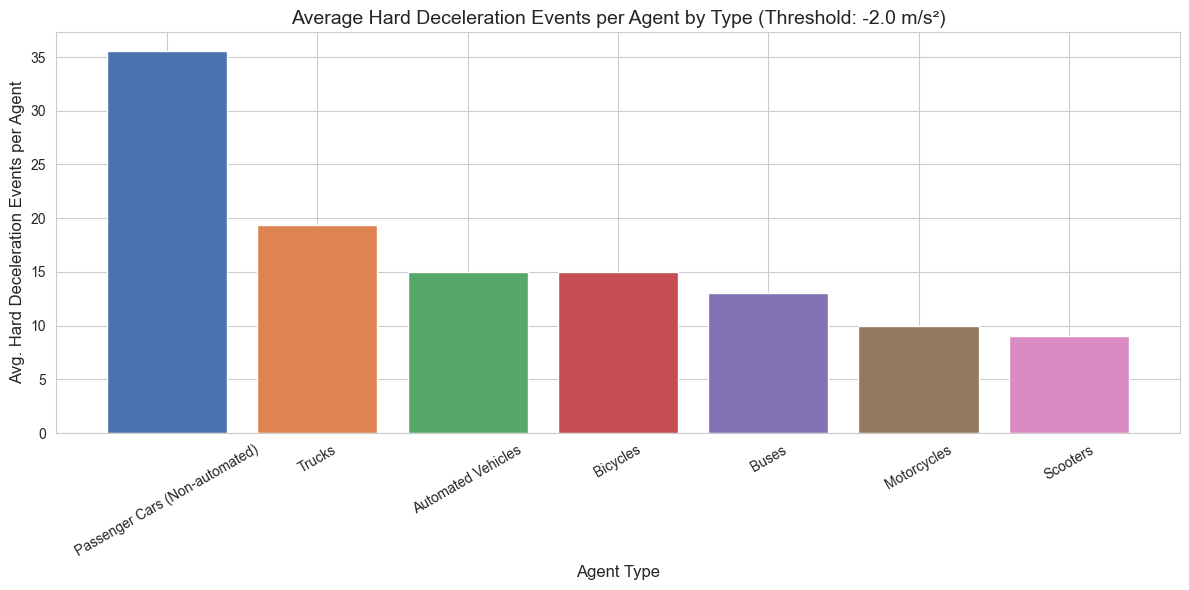

In [25]:
# Visualize average deceleration events per agent type
plt.figure(figsize = (12, 6))
plt.bar(decel_results.index, decel_results['avg_events_per_agent'],
        color = sns.color_palette('deep', len(decel_results)), edgecolor = 'white')
plt.xlabel('Agent Type', fontsize = 12)
plt.ylabel('Avg. Hard Deceleration Events per Agent', fontsize = 12)
plt.title('Average Hard Deceleration Events per Agent by Type (Threshold: -2.0 m/s²)', fontsize = 14)
plt.xticks(rotation = 30, fontsize = 10)
plt.tight_layout()
plt.show()

#### Function 3: `plot_agent_trajectories(df, agent_types, polygons)`

This function plots the physical trajectories of agents through the Foggy Bottom intersection, overlaid on the lane polygon layout provided in `Polygons.ipynb`. Each agent type is assigned a distinct color, and each individual agent's path is drawn by connecting their (x, y) positions in time order.

This directly satisfies Request #2 for a "visual representation of agent movement at the intersection", and allows us to visually compare how AVs navigate the space versus other agents.

In [26]:
# Intersection lane polygons (from Polygons.ipynb)
polygons = {
    1:  [(30.324748770225,331.53814563188763),(57.663676123074,331.53814563188763),(57.663676123074,316.0118742615324),(30.324748770225,316.0118742615324)],
    2:  [(175.21173304839542,330.9783041161296),(179.2799147295702,337.9390002953874),(191.839026066408,337.9390002953874),(191.839026066408,313.6792012792074),(178.9253484362568,309.5363740625982),(175.21173304839542,315.9745514938152)],
    3:  [(28.92514498083,170.9009533770588),(52.25187480408,170.9009533770588),(52.25187480408,155.9718462901788),(28.92514498083,155.9718462901788)],
    4:  [(174.8385053712234,169.8559158809772),(178.3655069204988,173.55086988498),(191.22320039907422,171.6474087314028),(191.22320039907422,155.3000364712692),(177.749681253165,155.8785393708858)],
    5:  [(41.521579085385,361.9935240891228),(45.4031469279738,361.9935240891228),(45.253855857105,337.864354759953),(41.334965246799,337.864354759953)],
    6:  [(41.3722880145162,309.4803899110224),(40.8870920341926,177.0592100503968),(44.7686598767814,177.0592100503968),(45.2165330893878,309.4803899110224)],
    7:  [(40.6631554278894,149.2724094849414),(44.246141128740604,149.2724094849414),(43.7236223806998,-0.0186613838586),(40.1406366798486,-0.0186613838586)],
    8:  [(45.4031469279738,361.9935240891228),(48.8368415579562,361.9935240891228),(48.6502277193702,337.864354759953),(45.253855857105,337.864354759953)],
    9:  [(45.2165330893878,309.4803899110224),(44.7686598767814,177.0592100503968),(48.5382594162186,177.0592100503968),(48.986132628825004,309.4803899110224)],
    10: [(47.9784179004606,149.2724094849414),(47.399915000844004,-0.0186613838586),(43.7236223806998,-0.0186613838586),(44.246141128740604,149.2724094849414)],
    11: [(52.3078589556558,361.9935240891228),(52.0092768139182,337.864354759953),(48.6502277193702,337.864354759953),(48.8368415579562,361.9935240891228)],
    12: [(51.9346312784838,177.0592100503968),(52.345181723373,309.4803899110224),(48.986132628825004,309.4803899110224),(48.5382594162186,177.0592100503968)],
    13: [(47.9784179004606,149.2724094849414),(51.5614036013118,149.2724094849414),(51.1881759241398,-0.0186613838586),(47.399915000844004,-0.0186613838586)],
    14: [(41.521579085385,361.9935240891228),(41.334965246799,337.864354759953),(37.3414291010586,337.864354759953),(37.6400112427962,361.9935240891228)],
    15: [(41.3722880145162,309.4803899110224),(40.8870920341926,177.0592100503968),(36.8935558884522,177.0592100503968),(37.3041063333414,309.4803899110224)],
    16: [(40.6631554278894,149.2724094849414),(40.1406366798486,-0.0186613838586),(36.3710371404114,-0.0186613838586),(36.9308786561694,149.2724094849414)],
    17: [(33.683797864773,361.9935240891228),(33.497184026187,337.864354759953),(37.3414291010586,337.864354759953),(37.6400112427962,361.9935240891228)],
    18: [(33.030649429722,177.0592100503968),(33.6464750970558,309.4803899110224),(37.3041063333414,309.4803899110224),(36.8935558884522,177.0592100503968)],
    19: [(36.9308786561694,149.2724094849414),(36.3710371404114,-0.0186613838586),(32.8253742072774,-0.0186613838586),(33.1986018844494,149.2724094849414)],
    20: [(33.683797864773,361.9935240891228),(33.497184026187,337.864354759953),(30.511362608811,337.864354759953),(30.79128336669,361.9935240891228)],
    21: [(33.030649429722,177.0592100503968),(33.6464750970558,309.4803899110224),(30.138134931639,309.4803899110224),(29.764907254467,177.0592100503968)],
    22: [(33.1986018844494,149.2724094849414),(32.8253742072774,-0.0186613838586),(29.4663251127294,-0.0186613838586),(29.764907254467,149.2724094849414)],
    23: [(179.14928504256,302.7249689542092),(182.88156181428,303.9566202888768),(182.6576252079768,177.9549564756096),(178.7387345976708,178.589443526802)],
    24: [(178.5521207590848,151.250516173953),(182.6203024402596,151.063902335367),(182.2470747630876,66.8264155976466),(178.21621584963,66.8264155976466)],
    25: [(182.88156181428,303.9566202888768),(187.4349394757784,305.486853765282),(187.1363573340408,177.2458238889828),(182.6576252079768,177.9549564756096)],
    26: [(182.6203024402596,151.063902335367),(186.50187028284842,151.1198864869428),(186.2032881411108,66.8264155976466),(182.2470747630876,66.8264155976466)],
    27: [(187.4349394757784,305.486853765282),(191.652412227822,306.9051189385356),(191.465798389236,176.5740140700732),(187.1363573340408,177.2458238889828)],
    28: [(186.50187028284842,151.1198864869428),(190.6446974994576,150.7653201936294),(190.3834381254372,66.8264155976466),(186.2032881411108,66.8264155976466)],
    29: [(168.512296243158,330.6423992066748),(168.512296243158,323.8496554821444),(64.56838815075601,323.7003644112756),(64.56838815075601,330.8476744291194)],
    30: [(168.512296243158,323.8496554821444),(168.512296243158,316.2358108678356),(64.56838815075601,316.2358108678356),(64.56838815075601,323.7003644112756)],
    31: [(0.0186613838586,169.2400902136434),(22.300353711027,169.2400902136434),(22.300353711027,163.193801843457),(0.0186613838586,163.193801843457)],
    32: [(169.7066248101084,169.538672355381),(171.0502444479276,163.4177384497602),(59.063279912469,163.4177384497602),(59.063279912469,169.538672355381)],
    33: [(0.0186613838586,163.193801843457),(22.300353711027,163.193801843457),(22.300353711027,157.2968045441394),(0.0186613838586,157.2968045441394)],
    34: [(171.0502444479276,163.4177384497602),(172.3192185503124,156.9235768669674),(59.063279912469,156.9235768669674),(59.063279912469,163.4177384497602)],
    35: [(178.402829688216,337.9390002953874),(192.21225374358,337.9390002953874),(192.21225374358,344.8437123230694),(178.402829688216,344.8437123230694)],
    36: [(178.9253484362568,309.5363740625982),(191.839026066408,313.6792012792074),(191.839026066408,307.0357486255458),(178.9253484362568,302.6689848026334)],
    37: [(175.21173304839542,330.9783041161296),(175.21173304839542,315.9745514938152),(168.512296243158,315.9745514938152),(168.512296243158,330.9783041161296)],
    38: [(191.839026066408,331.8740505413424),(196.87759970823,331.8740505413424),(196.87759970823,314.2390427949654),(191.839026066408,314.2390427949654)],
    39: [(29.764907254467,331.53814563188763),(53.744785512768004,331.53814563188763),(53.744785512768004,337.864354759953),(29.764907254467,337.864354759953)],
    40: [(29.764907254467,316.0118742615324),(53.744785512768004,316.0118742615324),(53.744785512768004,309.4803899110224),(29.764907254467,309.4803899110224)],
    41: [(57.663676123074,331.53814563188763),(64.56838815075601,331.53814563188763),(64.56838815075601,315.5453396650674),(57.663676123074,315.5453396650674)],
    42: [(178.3655069204988,173.55086988498),(192.77209525933802,171.4607948928168),(192.77209525933802,176.3314160799114),(178.3655069204988,178.57078214294341)],
    43: [(177.749681253165,155.8785393708858),(191.745719147115,155.3000364712692),(191.652412227822,150.7653201936294),(177.8803109401752,151.250516173953)],
    44: [(191.22320039907422,170.5837098514626),(195.90720774758282,170.7889850739072),(195.90720774758282,155.3000364712692),(191.22320039907422,155.3000364712692)],
    45: [(174.8385053712234,169.8559158809772),(177.469760495286,156.4383808866438),(172.5058323888984,156.4383808866438),(169.6693020423912,169.8559158809772)],
    46: [(28.92514498083,170.9009533770588),(52.625102481252,170.9009533770588),(52.625102481252,177.0592100503968),(28.92514498083,177.0592100503968)],
    47: [(28.738531142244,155.9718462901788),(52.625102481252,155.9718462901788),(52.625102481252,149.2724094849414),(28.738531142244,149.2724094849414)],
    48: [(52.25187480408,170.0425297195632),(59.063279912469,170.0425297195632),(59.063279912469,156.4570422705024),(52.25187480408,156.4570422705024)],
    49: [(28.92514498083,170.3597732451594),(28.92514498083,156.2704284319164),(22.300353711027,156.2704284319164),(22.300353711027,170.3597732451594)],
}

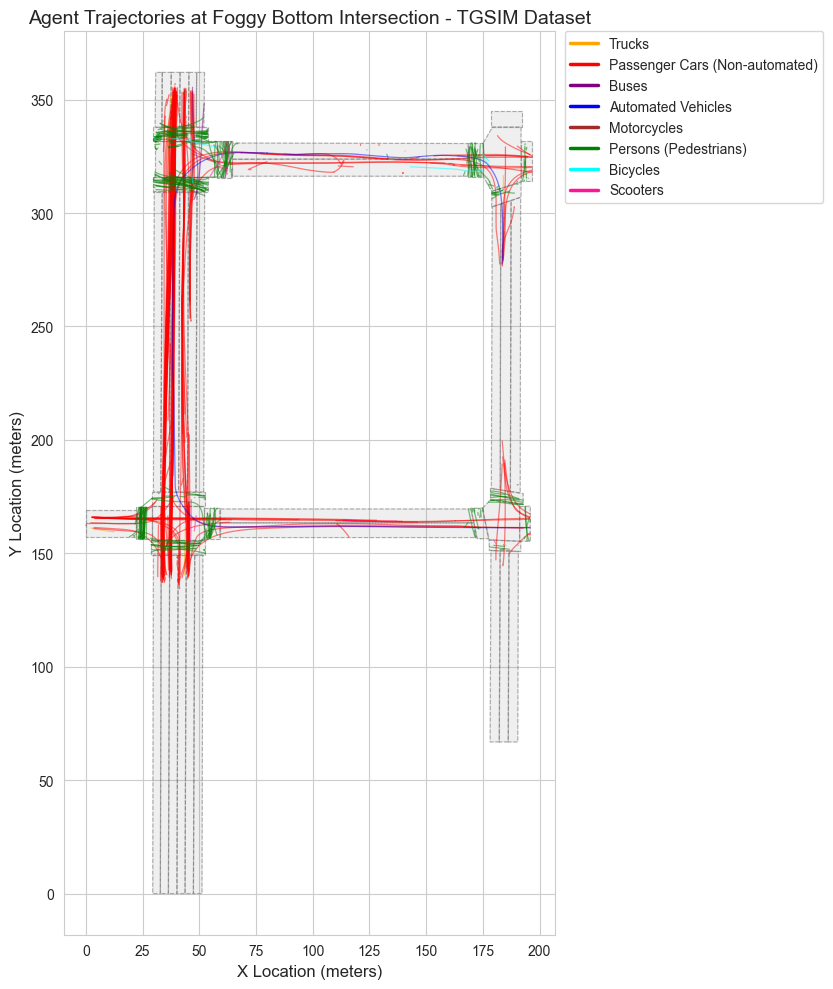

In [32]:
# Function 3: Plot agent trajectories overlaid on the intersection layout
def plot_agent_trajectories(df, agent_types, polygons):
    # Color map for each agent type
    color_map = {
        'Automated Vehicles'             : 'blue',
        'Passenger Cars (Non-automated)' : 'red',
        'Persons (Pedestrians)'          : 'green',
        'Trucks'                         : 'orange',
        'Buses'                          : 'purple',
        'Bicycles'                       : 'cyan',
        'Motorcycles'                    : 'brown',
        'Scooters'                       : 'deeppink'
    }
    fig, ax = plt.subplots(figsize = (14, 10))
    # Draw lane polygons from the intersection layout
    for lane_id, coords in polygons.items():
        coords_closed = coords + [coords[0]]
        x, y = zip(*coords_closed)
        ax.fill(x, y, alpha = 0.12, color = 'gray')
        ax.plot(x, y, linestyle = '--', linewidth = 0.8, color = 'gray', alpha = 0.6)
    # Plot the path of each individual agent, colored by type
    for agent_type in agent_types:
        agent_subset = df[df['agent_type_label'] == agent_type]
        color        = color_map.get(agent_type, 'black')
        for agent_id in agent_subset['id'].unique():
            path = agent_subset[agent_subset['id'] == agent_id].sort_values('time')
            ax.plot(path['xloc_kf'], path['yloc_kf'],
                    color = color, linewidth = 0.9, alpha = 0.5)
        # Add a legend proxy line for this agent type
        ax.plot([], [], color = color, linewidth = 2.5, label = agent_type)
    ax.set_xlabel('X Location (meters)', fontsize = 12)
    ax.set_ylabel('Y Location (meters)', fontsize = 12)
    ax.set_title('Agent Trajectories at Foggy Bottom Intersection - TGSIM Dataset', fontsize = 14)
    ax.legend(fontsize = 10, bbox_to_anchor = (1.02, 1), loc = 'upper left', borderaxespad = 0)
    ax.set_aspect('equal')
    plt.tight_layout(rect = [0, 0, 0.85, 1])
    plt.show()
# Call the function - plot all agent types
all_agent_types = tgsim_data['agent_type_label'].unique().tolist()
plot_agent_trajectories(tgsim_data, all_agent_types, polygons)

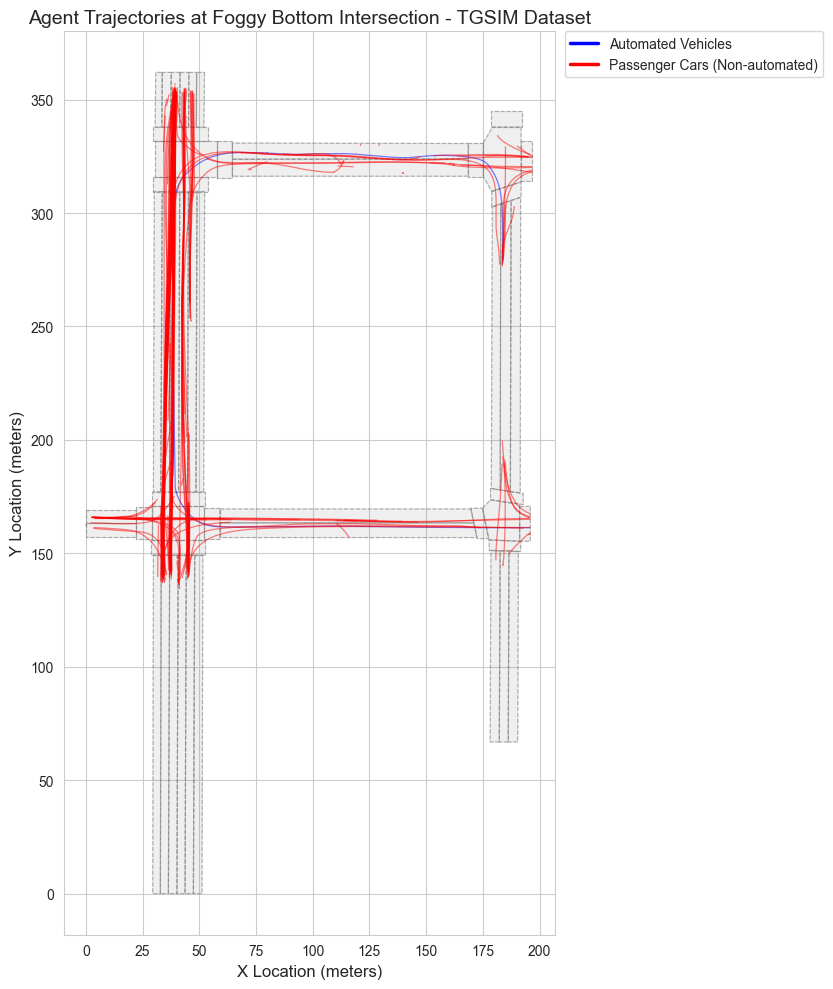

In [33]:
# This is to zoom in: Compare only AV and Passenger Car trajectories
av_and_cars = ['Automated Vehicles', 'Passenger Cars (Non-automated)']
plot_agent_trajectories(tgsim_data, av_and_cars, polygons)


#### The packages that were used:
---
| Package | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, grouping, and aggregation |
| `numpy` | Numerical support |
| `matplotlib` | Plotting all figures and trajectory maps |
| `seaborn` | Plot theming and color palette management |

Bias Note: Several analytical decisions in this notebook introduce potential bias. The deceleration threshold of -2.0 m/s^2 used in `count_decel_events()` is a cutoff pretty much changing this value would directly affect which events are counted as "disruptive." Similarly, the behavior classification bins in `classify_behavior()` were set based on engineering judgment rather than a published standard. Most critically, the dataset contains only 1 Automated Vehicle, making any AV-vs-human comparison statistically limited. These decisions should be disclosed to the client when presenting findings.